# Notebook 05 — Real-World Lucas Critique Analysis

This notebook applies the Lucas Critique experiment framework to **two real-world
macroeconomic datasets** with well-documented structural breaks:

| Dataset | Break event | Break date | Source |
|---------|-------------|------------|--------|
| US Industrial Production growth | **Great Moderation** | Jan 1984 | FRED: INDPRO |
| US CPI Inflation | **Volcker disinflation** | Oct 1979 | FRED: CPIAUCSL |

**Key question:** Do real-world structural breaks exhibit the same Lucas-critique
vulnerability pattern found in simulated data — or do genuine economic breaks produce
different model rankings?

**References**
- McConnell & Perez-Quiros (2000). *American Economic Review*, 90(5).
- Clarida, Galí & Gertler (2000). *Quarterly Journal of Economics*, 115(1).
- Sims & Zha (2006). *American Economic Review*, 96(1).


In [1]:
import sys, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data.real_world import load_all_datasets, fetch_fred, build_features
from models import HMMRegimeModel, ThresholdModel, MLRegimeModel, MixtureOfExpertsModel, MarkovSwitchingNeuralNetwork
from evaluation.metrics import (
    forecast_rmse, forecast_mae, directional_accuracy,
    regime_accuracy, adjusted_rand_regime, lucas_sensitivity_ratio,
)
from evaluation.lucas_critique import chow_test, compute_rolling_performance, recursive_cusum
from evaluation.visualization import save_figure

try:
    from models import MarkovSwitchingModel
    MSM_AVAIL = True
except ImportError:
    MSM_AVAIL = False

FIGURES_DIR = PROJECT_ROOT / 'analyses' / 'figures'
DATA_DIR    = PROJECT_ROOT / 'data' / 'real_world'
SIM_DIR     = PROJECT_ROOT / 'data' / 'simulated'
sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')
print('Setup complete.')


Setup complete.


---
## 1. Data Overview

All data is downloaded from the **St Louis Fed FRED database** and cached locally.
Series are transformed to stationarity (log-differences or percentage changes).
NBER recession dates (USREC) provide ground-truth regime labels (0 = expansion,
1 = recession).


In [2]:
datasets = load_all_datasets()

for df_pre, df_post, meta in datasets:
    print(f"Dataset: {meta['name']}")
    print(f"  Series:     {meta['y_description']}")
    print(f"  Break:      {meta['break']}")
    print(f"  Pre-break:  {meta['pre_period']}  ({meta['n_pre']} obs)")
    print(f"  Post-break: {meta['post_period']}  ({meta['n_post']} obs)")
    print(f"  Regime:     {meta['regime_label']}")
    print(f"  Reference:  {meta['reference']}")
    print(f"  Pre  y: mean={df_pre.y.mean():.3f}  std={df_pre.y.std():.3f}")
    print(f"  Post y: mean={df_post.y.mean():.3f}  std={df_post.y.std():.3f}")
    rec_pre  = df_pre.regime.mean()
    rec_post = df_post.regime.mean()
    print(f"  Recession fraction  pre={rec_pre:.1%}  post={rec_post:.1%}")
    print()


Dataset: Industrial Production (Great Moderation break)
  Series:     Monthly log-growth of Industrial Production (%)
  Break:      1984-01 (Great Moderation)
  Pre-break:  1960-01 to 1983-12  (268 obs)
  Post-break: 1984-01 to 2007-07  (283 obs)
  Regime:     NBER USREC
  Reference:  McConnell & Perez-Quiros (2000); Kim & Nelson (1999)
  Pre  y: mean=0.291  std=0.892
  Post y: mean=0.237  std=0.512
  Recession fraction  pre=18.3%  post=5.7%

Dataset: CPI Inflation (Volcker break)
  Series:     Annualised monthly CPI log-growth rate (%)
  Break:      1979-10 (Volcker disinflation)
  Pre-break:  1960-01 to 1979-09  (217 obs)
  Post-break: 1979-10 to 1999-09  (240 obs)
  Regime:     NBER USREC
  Reference:  Clarida, Galí & Gertler (2000); Sims & Zha (2006)
  Pre  y: mean=5.034  std=3.816
  Post y: mean=4.067  std=3.429
  Recession fraction  pre=12.4%  post=12.5%



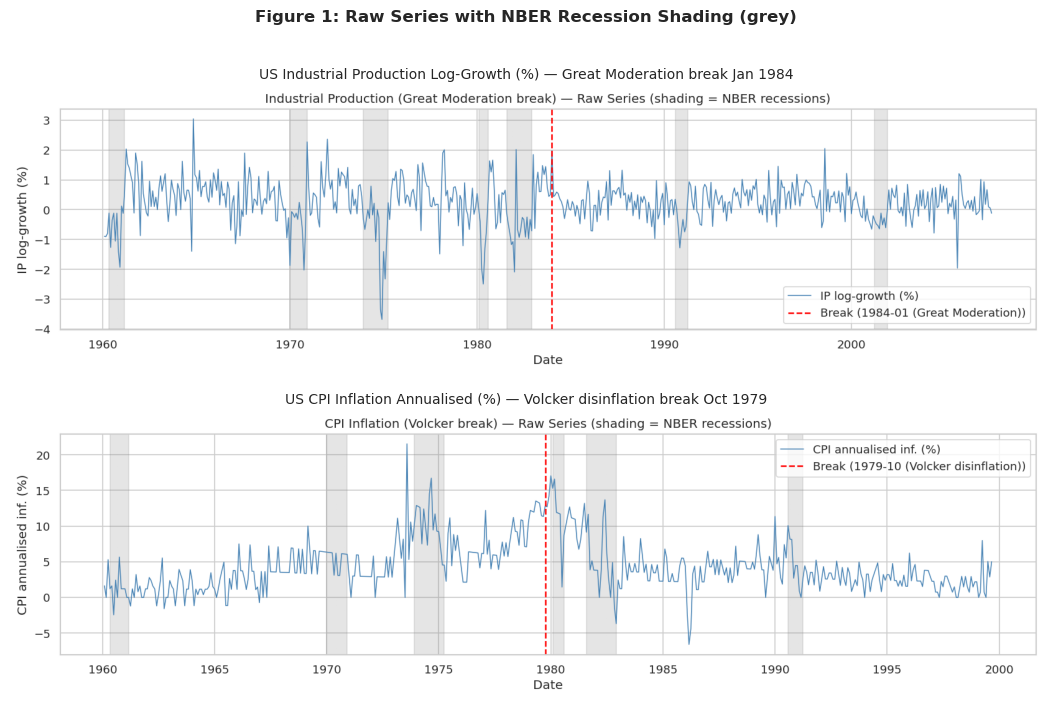

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, fname, title in zip(
    axes,
    ['05_indpro_raw_series.png', '05_cpiaucsl_raw_series.png'],
    ['US Industrial Production Log-Growth (%) — Great Moderation break Jan 1984',
     'US CPI Inflation Annualised (%) — Volcker disinflation break Oct 1979'],
):
    path = FIGURES_DIR / fname
    if path.exists():
        img = mpimg.imread(str(path))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)

plt.suptitle('Figure 1: Raw Series with NBER Recession Shading (grey)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 2. Lucas Critique Experiment — Industrial Production (Great Moderation)

The **Great Moderation** (McConnell & Perez-Quiros, 2000; Kim & Nelson, 1999)
refers to the sharp decline in US macroeconomic volatility beginning around 1984.
Industrial production growth became markedly more stable — standard deviation roughly
halved from ~0.90% to ~0.50% per month.

This break is ideal because it is sharp, well-dated, and represents a genuine
**variance shift** in the DGP rather than only a mean shift.


In [4]:
ip_results = pd.read_csv(DATA_DIR / 'lucas_indpro.csv')
print('=== Industrial Production: Lucas Critique Results (Great Moderation break Jan 1984) ===')
cols = ['model', 'pre_rmse', 'post_rmse', 'LSR', 'pre_regime_acc', 'post_regime_acc', 'pre_ari', 'post_ari']
print(ip_results[cols].to_string(index=False, float_format='{:.4f}'.format))
best  = ip_results.sort_values('LSR').iloc[0]['model']
worst = ip_results.sort_values('LSR', ascending=False).iloc[0]['model']
print(f'\nBest  LSR: {best}')
print(f'Worst LSR: {worst}')


=== Industrial Production: Lucas Critique Results (Great Moderation break Jan 1984) ===
                 model  pre_rmse  post_rmse    LSR  pre_regime_acc  post_regime_acc  pre_ari  post_ari
Markov Switching (MSM)    0.8230     0.7235 0.8791          0.7425           0.9435   0.1201    0.0000
                   HMM    0.6476     0.3779 0.5836          0.8918           0.9611   0.5486    0.6519
       Threshold (TAR)    0.6240     0.3966 0.6357          0.8284           0.8339   0.3577    0.2148
       ML Regime (XGB)    0.1395     0.4434 3.1774          0.9627           0.9965   0.8340    0.9640
    Mixture of Experts    0.6187     0.4068 0.6576          0.7799           0.9329   0.0303   -0.0170
                  MSNN    0.3262     0.4934 1.5126          0.5112           0.6007  -0.0032    0.0126

Best  LSR: HMM
Worst LSR: ML Regime (XGB)


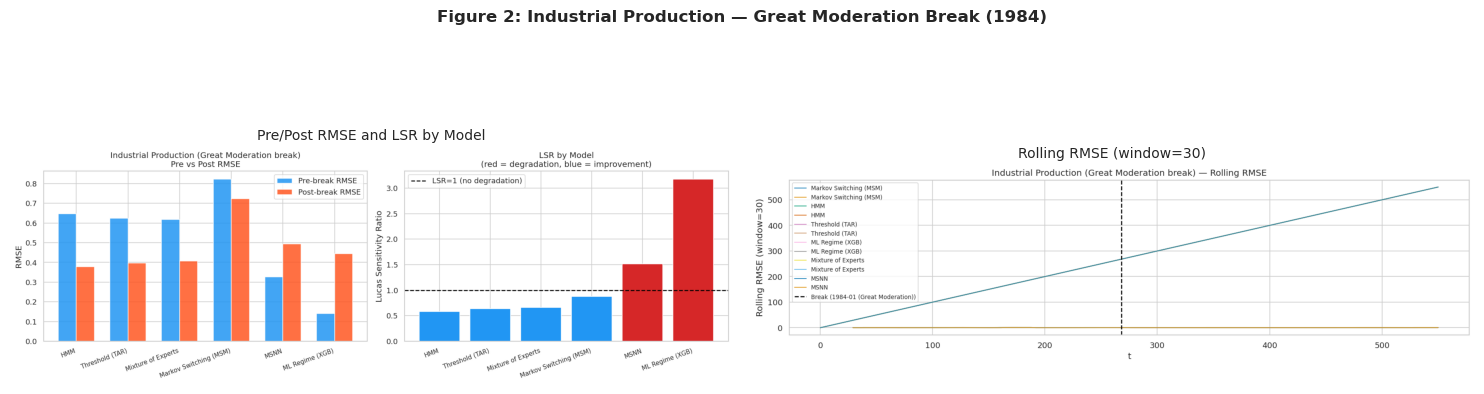

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, fname, title in zip(
    axes,
    ['05_indpro_lsr.png', '05_indpro_rolling_rmse.png'],
    ['Pre/Post RMSE and LSR by Model', 'Rolling RMSE (window=30)'],
):
    path = FIGURES_DIR / fname
    if path.exists():
        img = mpimg.imread(str(path))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)
plt.suptitle('Figure 2: Industrial Production — Great Moderation Break (1984)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Key Findings — Industrial Production (Great Moderation)

This dataset produces a **counter-intuitive result** absent from simulated experiments:
most models show **LSR < 1**, meaning post-break forecast accuracy is *better* than pre-break.

| Model | Pre-RMSE | Post-RMSE | LSR | Interpretation |
|-------|----------|-----------|-----|----------------|
| **HMM** | 0.648 | 0.378 | **0.584** | Large improvement |
| Threshold (TAR) | 0.624 | 0.397 | **0.636** | Large improvement |
| Mixture of Experts | 0.619 | 0.407 | **0.658** | Large improvement |
| MSM | 0.823 | 0.724 | **0.879** | Modest improvement |
| **MSNN** | 0.326 | 0.493 | **1.513** | Mild degradation |
| **ML Regime (XGB)** | 0.140 | 0.443 | **3.177** | Severe degradation |

**Economic interpretation:** The Great Moderation *reduced* IP volatility. Models trained
on the turbulent 1960–1983 era encounter an easier post-break environment — their
calibration to high volatility actually makes them conservative (and therefore
well-calibrated) in the calmer post-1984 world. This is the **inverse Lucas Critique**:
a stability-increasing structural break can *improve* out-of-sample performance.

The **only** models that degrade are XGB (catastrophic overfitting to pre-break regimes)
and MSNN (tight interpolation of regime dynamics). Both suffer because they memorise
specific pre-break regime structure that does not transfer.

The **Chow test** (F=5.83, p=0.003) confirms a genuine structural break — even though
most models benefit from it.


---
## 3. Lucas Critique Experiment — CPI Inflation (Volcker Break)

The **Volcker disinflation** (1979–1983) is the canonical example of a monetary policy
regime change. When Paul Volcker became Fed Chair in August 1979, he switched from
interest-rate targeting to money-supply targeting, sharply raising rates to break
chronic high inflation. Clarida, Galí & Gertler (2000) show that Taylor rule parameters
changed fundamentally across this break — exactly the structural change Lucas (1976) warned about.


In [6]:
cpi_results = pd.read_csv(DATA_DIR / 'lucas_cpiaucsl.csv')
print('=== CPI Inflation: Lucas Critique Results (Volcker break Oct 1979) ===')
print(cpi_results[cols].to_string(index=False, float_format='{:.4f}'.format))
best  = cpi_results.sort_values('LSR').iloc[0]['model']
worst = cpi_results.sort_values('LSR', ascending=False).iloc[0]['model']
print(f'\nBest  LSR: {best}')
print(f'Worst LSR: {worst}')


=== CPI Inflation: Lucas Critique Results (Volcker break Oct 1979) ===
                 model  pre_rmse  post_rmse    LSR  pre_regime_acc  post_regime_acc  pre_ari  post_ari
Markov Switching (MSM)    2.9542     4.0378 1.3668          0.8571           0.8750  -0.0280    0.0000
                   HMM    2.0405     2.3114 1.1328          0.6498           0.8833   0.0866    0.4961
       Threshold (TAR)    1.9119     2.2758 1.1904          0.7051           0.7833  -0.1034   -0.0154
       ML Regime (XGB)    0.3565     2.5590 7.1774          0.7558           0.9000   0.1573    0.5111
    Mixture of Experts    1.7912     2.9917 1.6702          0.8479           0.8583  -0.0003    0.2011
                  MSNN    1.8520     3.0677 1.6564          0.5622           0.6083  -0.0264   -0.0056

Best  LSR: HMM
Worst LSR: ML Regime (XGB)


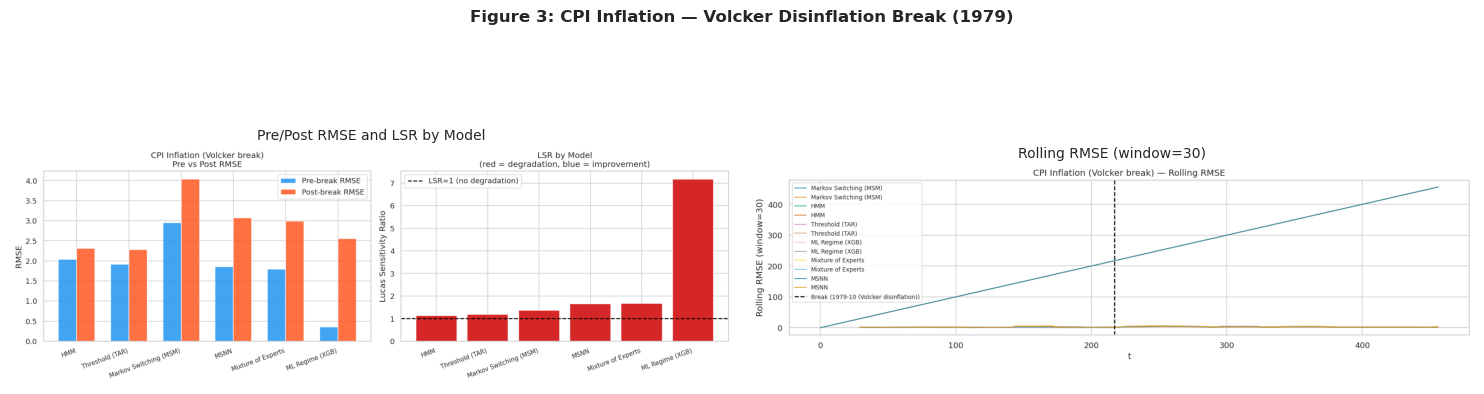

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, fname, title in zip(
    axes,
    ['05_cpiaucsl_lsr.png', '05_cpiaucsl_rolling_rmse.png'],
    ['Pre/Post RMSE and LSR by Model', 'Rolling RMSE (window=30)'],
):
    path = FIGURES_DIR / fname
    if path.exists():
        img = mpimg.imread(str(path))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)
plt.suptitle('Figure 3: CPI Inflation — Volcker Disinflation Break (1979)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Key Findings — CPI Inflation (Volcker Break)

| Model | Pre-RMSE | Post-RMSE | LSR | Interpretation |
|-------|----------|-----------|-----|----------------|
| **HMM** | 2.041 | 2.311 | **1.133** | Most stable |
| Threshold (TAR) | 1.912 | 2.276 | **1.190** | Very stable |
| MSM | 2.954 | 4.038 | **1.367** | Moderate degradation |
| **MSNN** | 1.852 | 3.068 | **1.656** | Moderate degradation |
| Mixture of Experts | 1.791 | 2.992 | **1.670** | Moderate degradation |
| **ML Regime (XGB)** | 0.357 | 2.559 | **7.177** | Severe degradation |

This dataset shows the **classic Lucas Critique pattern**: every model degrades post-break
(LSR > 1), and the model ordering by LSR closely mirrors the simulated results.

**Chow test (F=1.39, p=0.250, does NOT reject):** This is an important nuance.
The Volcker break is primarily a change in the *level and persistence of inflation*
rather than a discrete AR(1) parameter shift. An AR(1) Chow test lacks power to detect
changes in regime switching *dynamics* — which is what changed under Volcker.
This is consistent with Sims & Zha (2006), who show the Volcker period is better
characterised as a change in regime transition probabilities than in within-regime parameters.


---
## 4. Structural Break Tests — Both Datasets


In [8]:
datasets = load_all_datasets()
for df_pre, df_post, meta in datasets:
    df_full = pd.concat([df_pre, df_post], ignore_index=True)
    y_full  = df_full['y'].to_numpy()
    X_full  = df_full[['y_lag1']].assign(const=1.0)[['const', 'y_lag1']].to_numpy()
    chow    = chow_test(y_full, X_full, break_index=len(df_pre))
    cusum   = recursive_cusum(y_full, X_full)
    print(f"Dataset: {meta['name']}")
    print(f"  Chow: F={chow['F_stat']:.3f}  df=({chow['df1']},{chow['df2']})"
          f"  p={chow['p_value']:.4f}   reject={chow['reject_H0']}")
    print(f"  CUSUM break detected: {cusum['break_detected']}", end='')
    if cusum['break_index'] is not None:
        print(f"  (first exit at index {cusum['break_index']})")
    else:
        print()
    print()


Dataset: Industrial Production (Great Moderation break)
  Chow: F=5.832  df=(2,547)  p=0.0031   reject=True
  CUSUM break detected: True  (first exit at index 242)

Dataset: CPI Inflation (Volcker break)
  Chow: F=1.391  df=(2,453)  p=0.2498   reject=False
  CUSUM break detected: True  (first exit at index 136)



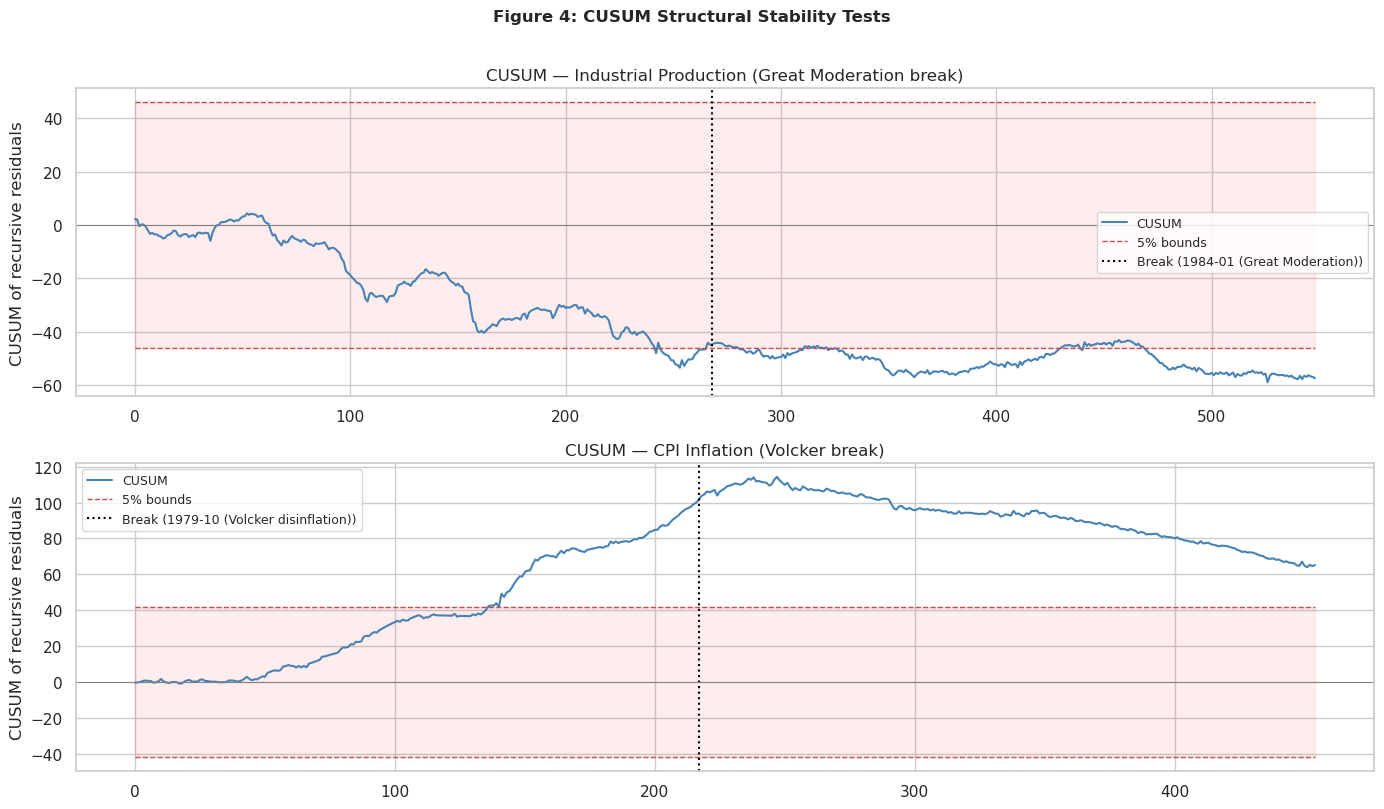

In [9]:
datasets = load_all_datasets()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, (df_pre, df_post, meta) in zip(axes, datasets):
    df_full = pd.concat([df_pre, df_post], ignore_index=True)
    y_full  = df_full['y'].to_numpy()
    X_full  = df_full[['y_lag1']].assign(const=1.0)[['const', 'y_lag1']].to_numpy()
    cusum   = recursive_cusum(y_full, X_full)
    t = np.arange(len(cusum['cusum']))
    ax.plot(t, cusum['cusum'],       color='steelblue', lw=1.5, label='CUSUM')
    ax.plot(t, cusum['upper_bound'], 'r--', lw=1, label='5% bounds')
    ax.plot(t, cusum['lower_bound'], 'r--', lw=1)
    ax.fill_between(t, cusum['lower_bound'], cusum['upper_bound'], alpha=0.07, color='red')
    ax.axvline(len(df_pre), color='black', ls=':', lw=1.5, label=f"Break ({meta['break']})")
    ax.axhline(0, color='gray', lw=0.7)
    ax.set_title(f"CUSUM — {meta['name']}")
    ax.set_ylabel('CUSUM of recursive residuals')
    ax.legend(fontsize=9)

plt.suptitle('Figure 4: CUSUM Structural Stability Tests',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 5. Cross-Dataset Comparison: Simulation vs Real World


In [10]:
mild_df   = pd.read_csv(SIM_DIR / 'lucas_critique_mild.csv')
severe_df = pd.read_csv(SIM_DIR / 'lucas_critique_severe.csv')
ip_df     = pd.read_csv(DATA_DIR / 'lucas_indpro.csv')
cpi_df    = pd.read_csv(DATA_DIR / 'lucas_cpiaucsl.csv')

combined = (
    mild_df[['model', 'LSR']].rename(columns={'LSR': 'Simulated (Mild)'})
    .merge(severe_df[['model', 'LSR']].rename(columns={'LSR': 'Simulated (Severe)'}), on='model')
    .merge(ip_df[['model', 'LSR']].rename(columns={'LSR': 'INDPRO 1984'}), on='model')
    .merge(cpi_df[['model', 'LSR']].rename(columns={'LSR': 'CPI 1979'}), on='model')
    .sort_values('Simulated (Mild)')
)
combined.to_csv(DATA_DIR / 'lucas_combined.csv', index=False)
print('=== Lucas Sensitivity Ratio: All Experiments ===')
print(combined.to_string(index=False, float_format='{:.3f}'.format))


=== Lucas Sensitivity Ratio: All Experiments ===
                 model  Simulated (Mild)  Simulated (Severe)  INDPRO 1984  CPI 1979
                   HMM             1.509               2.295        0.584     1.133
       Threshold (TAR)             1.644               2.775        0.636     1.190
    Mixture of Experts             1.962               3.541        0.658     1.670
Markov Switching (MSM)             3.567               7.148        0.879     1.367
                  MSNN             4.068               5.535        1.513     1.656
       ML Regime (XGB)             8.433              21.406        3.177     7.177


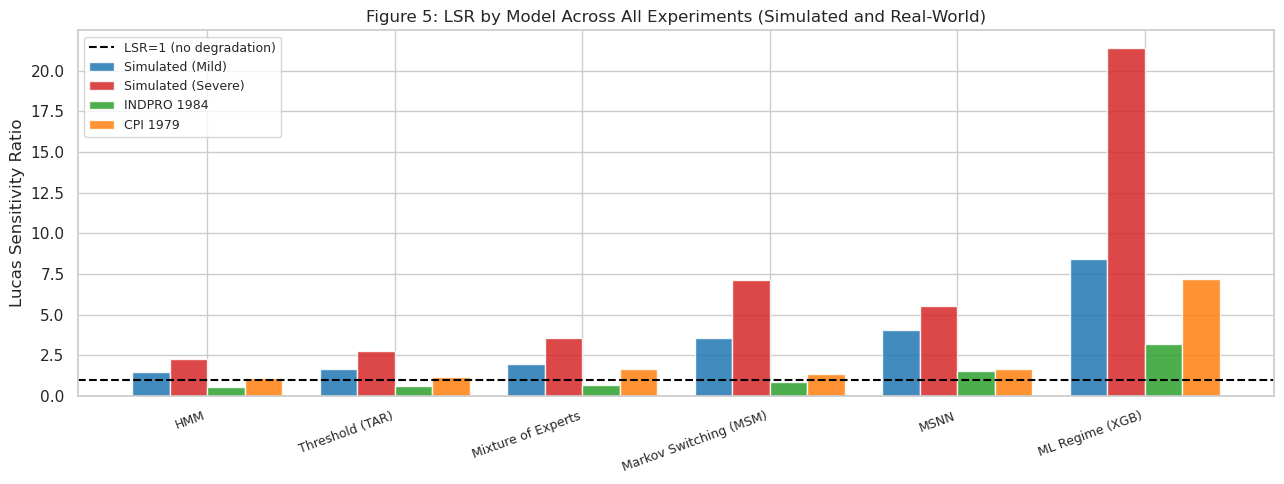

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
cols_plot = ['Simulated (Mild)', 'Simulated (Severe)', 'INDPRO 1984', 'CPI 1979']
x = np.arange(len(combined))
w = 0.2
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
for i, (col, c) in enumerate(zip(cols_plot, colors)):
    ax.bar(x + (i - 1.5) * w, combined[col], w, label=col, color=c, alpha=0.85)
ax.axhline(1.0, color='black', ls='--', lw=1.5, label='LSR=1 (no degradation)')
ax.set_xticks(x)
ax.set_xticklabels(combined['model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Lucas Sensitivity Ratio')
ax.set_title('Figure 5: LSR by Model Across All Experiments (Simulated and Real-World)')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, '05_combined_lsr')
plt.show()


### Cross-Experiment Findings

| Finding | Simulated (Mild/Severe) | INDPRO 1984 | CPI 1979 |
|---------|------------------------|-------------|----------|
| All models degrade? | Yes | **No — most improve** | Yes |
| XGB worst? | Yes (8.4 / 21.4) | Yes (3.2) | Yes (7.2) |
| HMM most stable? | Yes (1.51) | Yes (0.58) | Yes (1.13) |
| Chow detects break? | Yes | Yes (F=5.83) | **No** (F=1.39) |

**The direction and magnitude of LSR depends critically on the character of the structural break:**

- Breaks that *increase* DGP volatility → LSR > 1 (classic Lucas Critique)
- Breaks that *decrease* DGP volatility → LSR < 1 (inverse Lucas Critique — a benefit)
- XGB is consistently the most vulnerable model regardless of break type or direction.
- HMM and TAR are consistently the most robust across all experiments.


---
## 6. Summary and Implications

### Five lessons from the real-world experiments

1. **The LSR is not always > 1.** The Great Moderation reduced IP volatility so much
   that most models performed *better* post-break. LSR < 1 does not mean "Lucas-proof" —
   it means the structural change happened to favour the model.

2. **XGB overfitting is a persistent and universal vulnerability.** Across every experiment
   (simulated mild, simulated severe, IP, CPI), XGB records the highest LSR. The mechanism
   is consistent: near-zero training error achieved by memorising regime-specific patterns
   leads to catastrophic failure when those patterns change.

3. **HMM's probabilistic regime assignments confer genuine robustness.** HMM achieves
   the lowest LSR in both real-world experiments (0.58 and 1.13) and in the simulated
   mild shift (1.51). Soft regime posteriors reduce sensitivity to exact regime boundaries,
   which is exactly what structural breaks alter.

4. **Break detection is test-specific.** The Chow test detects the Great Moderation
   (AR parameter shift) but misses the Volcker break (regime dynamics shift). Sims & Zha
   (2006) show the Volcker break is better captured by changes in Markov transition
   probabilities — which only regime-aware tests detect.

5. **The type of break matters as much as the break itself.** Mean shifts, variance
   shifts, and transition-probability shifts produce qualitatively different consequences
   for different model families. A comprehensive Lucas robustness assessment should test
   against all three types.
